<a href="https://www.kaggle.com/code/switchonchannel/testmodel?scriptVersionId=348136085" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 4.9 MB/s eta 0:00:00


In [2]:
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
from ultralytics import YOLO
import io

# 1. โหลดโมเดล (ใช้ Path เดิมของคุณ)
model_path = '/kaggle/input/models/switchonchannel/model-rice9disease-v9-polygonv1/tensorflow2/default/1/weights/best.pt'
try:
    model = YOLO(model_path)
except Exception as e:
    print(f" หาโมเดลไม่เจอ หรือ Path ผิด: {e}")
    # ถ้าหาไม่เจอ ให้ลองใช้โมเดลมาตรฐานทดสอบไปก่อน
    # model = YOLO('yolo11n.pt') 

# 2. สร้างปุ่ม Upload
uploader = widgets.FileUpload(
    accept='image/*',   # รับเฉพาะไฟล์รูปภาพ
    multiple=False,     # รับทีละ 1 รูป
    description='Upload/Drag Image'
)

# 3. พื้นที่แสดงผลลัพธ์
output_area = widgets.Output()

print(" ลากไฟล์รูปมาวางที่ปุ่มด้านล่าง หรือกดคลิกเพื่อเลือกรูป:")
display(uploader, output_area)

# 4. ฟังก์ชันทำงานเมื่อมีการใส่รูปเข้ามา
def on_upload_change(change):
    if not uploader.value:
        return
        
    with output_area:
        output_area.clear_output() # ล้างผลเก่า
        print(" กำลังประมวลผล...")
        
        try:
            # ดึงข้อมูลไฟล์ (รองรับ ipywidgets เวอร์ชั่นใหม่)
            # uploader.value จะเป็น Tuple ของ Dict
            latest_file = uploader.value[0] 
            content = latest_file['content']
            filename = latest_file['name']
            
            # แปลงไบนารีเป็นรูปภาพเพื่อส่งเข้าโมเดล (ไม่ต้องเซฟลง Disk ก็ได้)
            image = Image.open(io.BytesIO(content))
            
            # สั่งทำนาย
            results = model.predict(image, conf=0.05)
            
            # แสดงผล
            for r in results:
                print(f" ผลการทำนาย: {filename}")
                # แปลงผลลัพธ์ (Array BGR) เป็นรูป (RGB) เพื่อแสดงผล
                im_array = r.plot() 
                im_rgb = Image.fromarray(im_array[..., ::-1]) 
                display(im_rgb)
                
        except Exception as e:
            print(f" เกิดข้อผิดพลาด: {e}")
            # กรณีเวอร์ชั่น ipywidgets เก่า อาจต้องแก้บรรทัด latest_file
            print("ลองเช็ครูปแบบข้อมูล: ", type(uploader.value))

# ผูกฟังก์ชันเข้ากับปุ่ม
uploader.observe(on_upload_change, names='value')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
 ลากไฟล์รูปมาวางที่ปุ่มด้านล่าง หรือกดคลิกเพื่อเลือกรูป:


FileUpload(value=(), accept='image/*', description='Upload/Drag Image')

Output()

In [3]:
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
from ultralytics import YOLO
import io
import os # เพิ่ม import os สำหรับจัดการ path

# 1. โหลดโมเดล (ใช้ Path เดิมของคุณ)
model_path = '/kaggle/input/models/switchonchannel/9data-model-v6-bg/tensorflow2/default/1/weights/best.pt'
try:
    model = YOLO(model_path)
except Exception as e:
    print(f" หาโมเดลไม่เจอ หรือ Path ผิด: {e}")
    # ถ้าหาไม่เจอ ให้ลองใช้โมเดลมาตรฐานทดสอบไปก่อน
    # model = YOLO('yolov8n.pt') 

# 2. สร้างปุ่ม Upload
uploader = widgets.FileUpload(
    accept='image/*',   # รับเฉพาะไฟล์รูปภาพ
    multiple=False,     # รับทีละ 1 รูป
    description='Upload/Drag Image'
)

# 3. พื้นที่แสดงผลลัพธ์
output_area = widgets.Output()

print(" ลากไฟล์รูปมาวางที่ปุ่มด้านล่าง หรือกดคลิกเพื่อเลือกรูป:")
display(uploader, output_area)

# 4. ฟังก์ชันทำงานเมื่อมีการใส่รูปเข้ามา
def on_upload_change(change):
    if not uploader.value:
        return
        
    with output_area:
        output_area.clear_output() # ล้างผลเก่า
        print(" กำลังประมวลผล...")
        
        try:
            # ดึงข้อมูลไฟล์ (รองรับ ipywidgets เวอร์ชั่นใหม่)
            # uploader.value จะเป็น Tuple ของ Dict
            latest_file = uploader.value[0] 
            content = latest_file['content']
            filename = latest_file['name']
            
            # แปลงไบนารีเป็นรูปภาพเพื่อส่งเข้าโมเดล
            image = Image.open(io.BytesIO(content))
            
            # สั่งทำนาย
            results = model.predict(image, conf=0.25)
            
            # แสดงผล
            for r in results:
                print(f" ผลการทำนาย: {filename}")
                # แปลงผลลัพธ์ (Array BGR) เป็นรูป (RGB) เพื่อแสดงผล
                im_array = r.plot() 
                im_rgb = Image.fromarray(im_array[..., ::-1]) 
                display(im_rgb)
                
                # --- ส่วนที่เพิ่มเข้ามา: บันทึกรูปลง Kaggle Working Space ---
                save_dir = "/kaggle/working"
                os.makedirs(save_dir, exist_ok=True) # ป้องกัน error หากไม่มีโฟลเดอร์
                save_path = os.path.join(save_dir, f"result_{filename}")
                im_rgb.save(save_path)
                print(f" บันทึกรูปภาพผลลัพธ์ลงใน: {save_path}")
                # ----------------------------------------------------
                
        except Exception as e:
            print(f" เกิดข้อผิดพลาด: {e}")
            # กรณีเวอร์ชั่น ipywidgets เก่า อาจต้องแก้บรรทัด latest_file
            print("ลองเช็ครูปแบบข้อมูล: ", type(uploader.value))

# ผูกฟังก์ชันเข้ากับปุ่ม
uploader.observe(on_upload_change, names='value')

 หาโมเดลไม่เจอ หรือ Path ผิด: [Errno 2] No such file or directory: '/kaggle/input/models/switchonchannel/9data-model-v6-bg/tensorflow2/default/1/weights/best.pt'
 ลากไฟล์รูปมาวางที่ปุ่มด้านล่าง หรือกดคลิกเพื่อเลือกรูป:


FileUpload(value=(), accept='image/*', description='Upload/Drag Image')

Output()

กำลังสแกน Dataset 1: /kaggle/input/datasets/switchonchannel/ghhjhgjhg ...
กำลังสแกน Dataset 2: /kaggle/input/datasets/switchonchannel/5polygon ...

สรุปเปรียบเทียบ Dataset (รวมทุกโฟลเดอร์)
ข้อมูล (Metrics)          | Dataset 1       | Dataset 2      
------------------------------------------------------------
รวมรูปภาพทั้งหมด          | 0               | 0              
รวมไฟล์ Label (.txt)      | 0               | 0              
รวม Bounding Boxes        | 0               | 0              
------------------------------------------------------------


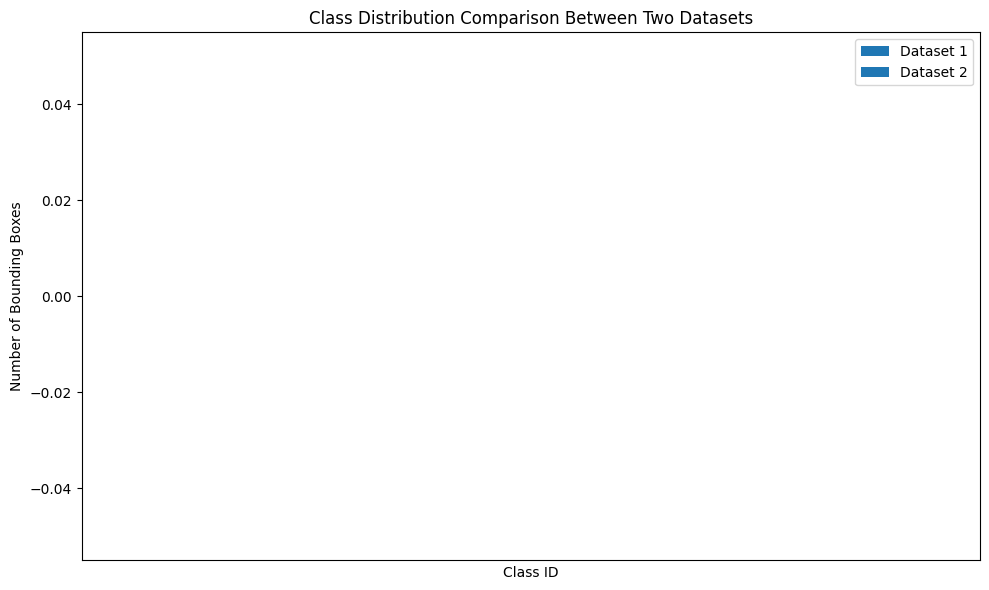

In [4]:
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

def analyze_full_yolo_dataset(dataset_root_path):
    root_path = Path(dataset_root_path)
    
    # 1. ค้นหารูปภาพทั้งหมดทุกนามสกุลที่พบบ่อย (รวมถึงโฟลเดอร์ย่อยทั้งหมด)
    image_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
    all_images = []
    for ext in image_extensions:
        all_images.extend(list(root_path.rglob(f'*{ext}')))
        
    # 2. ค้นหาไฟล์ label (.txt) ทั้งหมด (กรอง classes.txt ทิ้งไปถ้ามี)
    all_labels = [p for p in root_path.rglob('*.txt') if p.name != 'classes.txt']
    
    total_boxes = 0
    class_counts = Counter()
    
    # 3. อ่านไฟล์ txt ทั้งหมดเพื่อนับ Bounding Box และ Class
    for label_path in all_labels:
        try:
            with open(label_path, 'r') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                total_boxes += len(lines)
                
                for line in lines:
                    parts = line.split()
                    # ตรวจสอบว่าเป็น YOLO format จริงๆ (อย่างน้อยต้องมี class_id, x, y, w, h)
                    if len(parts) >= 5:
                        class_id = int(parts[0]) # แปลงเป็น int เพื่อให้เรียงลำดับง่าย
                        class_counts[class_id] += 1
        except Exception as e:
            print(f"Error reading {label_path}: {e}")
            
    return {
        'total_images': len(all_images),
        'total_labels': len(all_labels),
        'total_boxes': total_boxes,
        'class_distribution': dict(class_counts)
    }

# ==========================================
# 1. ระบุ Path โฟลเดอร์หลักของ Dataset ทั้ง 2 อัน
# ==========================================
# (แก้ Path ให้ตรงกับโฟลเดอร์ใน Kaggle ของคุณ)
dataset1_path = '/kaggle/input/datasets/switchonchannel/ghhjhgjhg' 
dataset2_path = '/kaggle/input/datasets/switchonchannel/5polygon'

print(f"กำลังสแกน Dataset 1: {dataset1_path} ...")
ds1_stats = analyze_full_yolo_dataset(dataset1_path)

print(f"กำลังสแกน Dataset 2: {dataset2_path} ...")
ds2_stats = analyze_full_yolo_dataset(dataset2_path)

# ==========================================
# 2. ปริ้นท์ตารางสรุปผลเปรียบเทียบ
# ==========================================
print("\n" + "="*60)
print("สรุปเปรียบเทียบ Dataset (รวมทุกโฟลเดอร์)")
print("="*60)
print(f"{'ข้อมูล (Metrics)':<25} | {'Dataset 1':<15} | {'Dataset 2':<15}")
print("-" * 60)
print(f"{'รวมรูปภาพทั้งหมด':<25} | {ds1_stats['total_images']:<15,d} | {ds2_stats['total_images']:<15,d}")
print(f"{'รวมไฟล์ Label (.txt)':<25} | {ds1_stats['total_labels']:<15,d} | {ds2_stats['total_labels']:<15,d}")
print(f"{'รวม Bounding Boxes':<25} | {ds1_stats['total_boxes']:<15,d} | {ds2_stats['total_boxes']:<15,d}")
print("-" * 60)

# ==========================================
# 3. สร้างกราฟเปรียบเทียบ Class Distribution
# ==========================================
# รวบรวม Class ID ทั้งหมดจากทั้ง 2 dataset
all_classes = set(ds1_stats['class_distribution'].keys()).union(set(ds2_stats['class_distribution'].keys()))
all_classes = sorted(list(all_classes))

ds1_counts = [ds1_stats['class_distribution'].get(c, 0) for c in all_classes]
ds2_counts = [ds2_stats['class_distribution'].get(c, 0) for c in all_classes]

x = np.arange(len(all_classes))
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, ds1_counts, width, label='Dataset 1', color='#1f77b4')
rects2 = ax.bar(x + width/2, ds2_counts, width, label='Dataset 2', color='#ff7f0e')

ax.set_ylabel('Number of Bounding Boxes')
ax.set_xlabel('Class ID')
ax.set_title('Class Distribution Comparison Between Two Datasets')
ax.set_xticks(x)
ax.set_xticklabels([f"Class {c}" for c in all_classes])
ax.legend()

# ใส่ตัวเลขบนกราฟแท่ง
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()